In [416]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score
)

In [453]:

df = pd.read_csv('heart_disease_uci.csv')

print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]}')
df.head()

Dataset Shape: (920, 16)
Rows: 920 | Columns: 16


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [454]:
# --- 3.1 Data Types & Basic Info ---
print('='*50)
print('DATASET INFO')
print('='*50)
df.info()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [455]:
# --- 3.2 Summary Statistics ---
print('\nSUMMARY STATISTICS')
df.describe().round(2)


SUMMARY STATISTICS


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.00,920.00,861.00,890.00,865.00,858.00,309.00,920.00
mean,460.50,53.51,132.13,199.13,137.55,0.88,0.68,1.00
std,265.73,9.42,19.07,110.78,25.93,1.09,0.94,1.14
min,1.00,28.00,0.00,0.00,60.00,-2.60,0.00,0.00
25%,230.75,47.00,120.00,175.00,120.00,0.00,0.00,0.00
50%,460.50,54.00,130.00,223.00,140.00,0.50,0.00,1.00
75%,690.25,60.00,140.00,268.00,157.00,1.50,1.00,2.00
max,920.00,77.00,200.00,603.00,202.00,6.20,3.00,4.00


In [456]:
# --- 3.4 Duplicate Rows ---
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found.')

Duplicate rows: 0
No duplicates found.


In [457]:
df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

df["num"].value_counts()

num
1    509
0    411
Name: count, dtype: int64

In [458]:
# --- 3.5 Target Variable Distribution ---
print('Target Variable Distribution:')
print(df['num'].value_counts())
print(f'\nClass balance: {df["num"].value_counts(normalize=True).round(3).to_dict()}')

Target Variable Distribution:
num
1    509
0    411
Name: count, dtype: int64

Class balance: {1: 0.553, 0: 0.447}


C:\Users\wwwzb\AppData\Local\Temp\ipykernel_13644\123250912.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="num", data=df,palette="Set2")


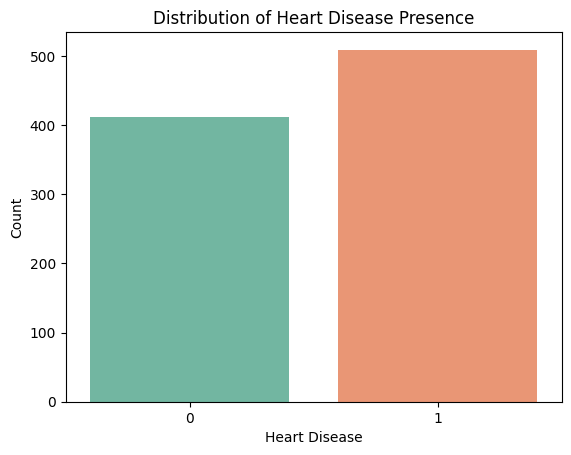

In [459]:
sns.countplot(x="num", data=df,palette="Set2")
plt.title("Distribution of Heart Disease Presence")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

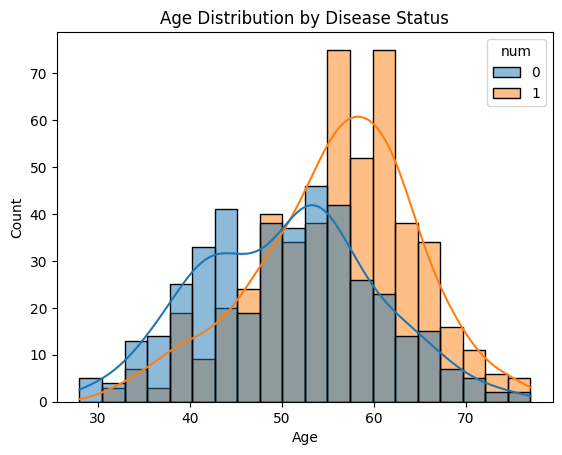

In [424]:
sns.histplot(x="age", data=df, hue='num',bins=20, kde=True)
plt.title("Age Distribution by Disease Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [425]:
df.isnull().sum()


id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [426]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')

In [427]:
df.drop(columns=['id'], inplace=True)

In [428]:
# df.drop(columns=['thal'], inplace=True)
df["thal"] = df["thal"].fillna("Unknown")

In [429]:
df.columns

Index(['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')

In [430]:
df.isnull().sum()

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal          0
num           0
dtype: int64

In [431]:
# df.dropna(subset=["fbs","exang"], inplace=True)

In [432]:
print("Missing values per column:")
print(df.isnull().sum())

# --- Categorical columns: fill with mode ---
categorical_cols = ['restecg', 'slope','fbs', 'exang']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# --- Numerical columns: fill with median ---
numerical_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after handling:")
print(df.isnull().sum())
print("\nShape after cleaning:", df.shape)

Missing values per column:
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal          0
num           0
dtype: int64

Missing values after handling:
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

Shape after cleaning: (920, 15)


In [462]:
num_cols = [ 'age','trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

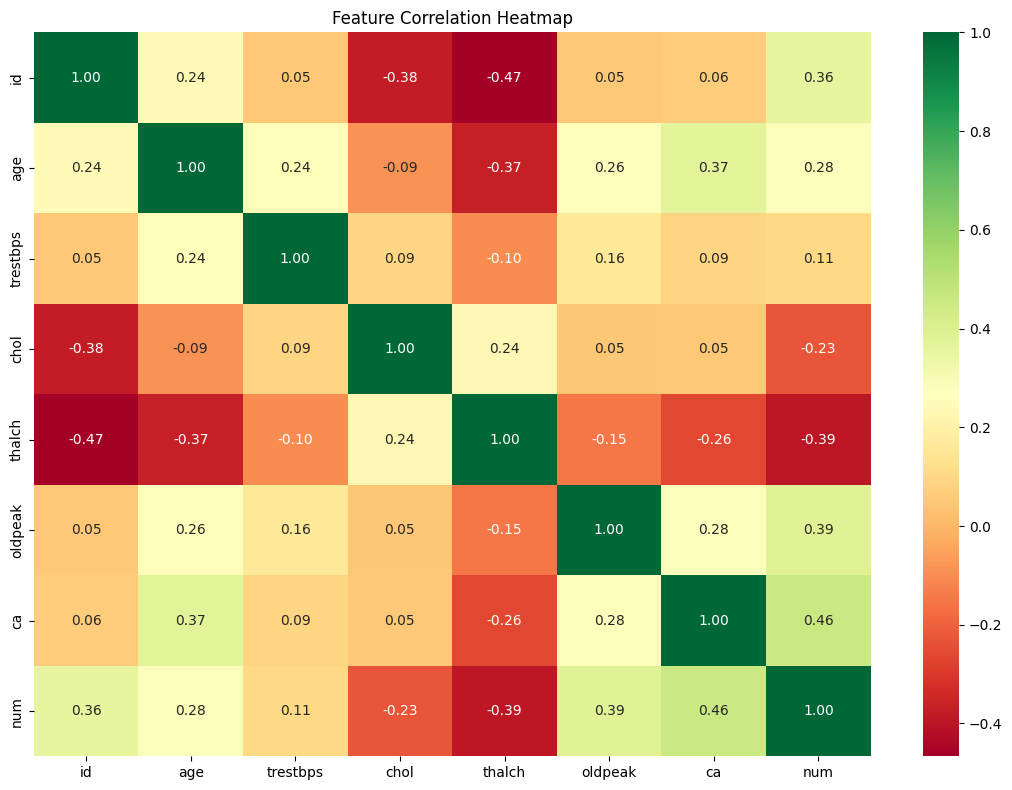


Top correlations with target:
ca          0.456
oldpeak     0.386
id          0.356
age         0.283
trestbps    0.106
chol       -0.231
thalch     -0.395
Name: num, dtype: float64


In [465]:
plt.figure(figsize=(11, 8))

numeric_df = df.select_dtypes(include=["int64", "float64"])

corr = numeric_df.corr()


sns.heatmap(corr,  annot=True, fmt='.2f',
            cmap='RdYlGn')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print("\nTop correlations with target:")
print(corr['num'].drop('num').sort_values(ascending=False).round(3))

In [433]:
num_cols = [ 'age','trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

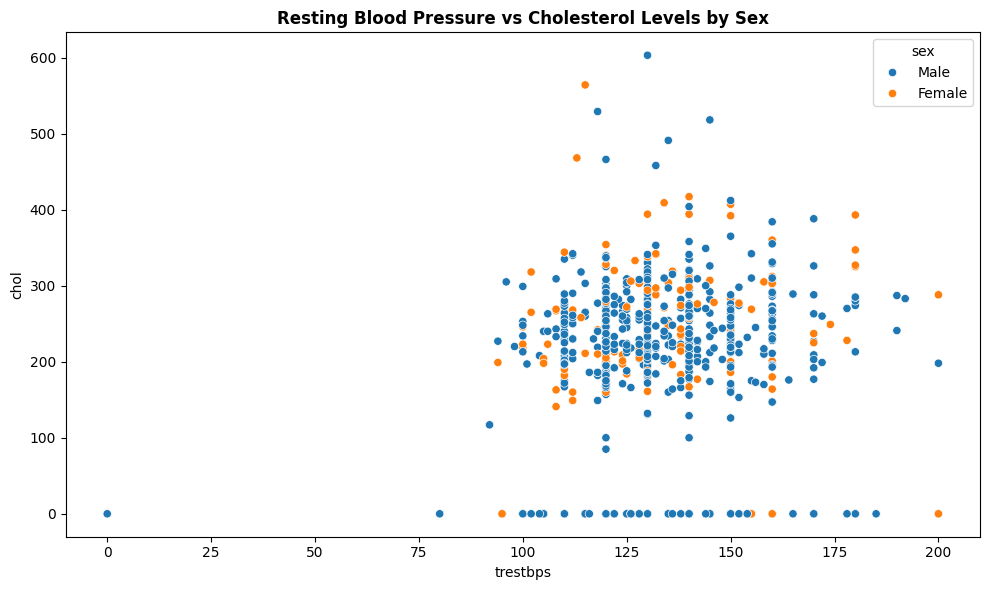

In [474]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='trestbps', y='chol', hue='sex')
plt.title('Resting Blood Pressure vs Cholesterol Levels by Sex', fontweight='bold')
plt.tight_layout()  
plt.show()

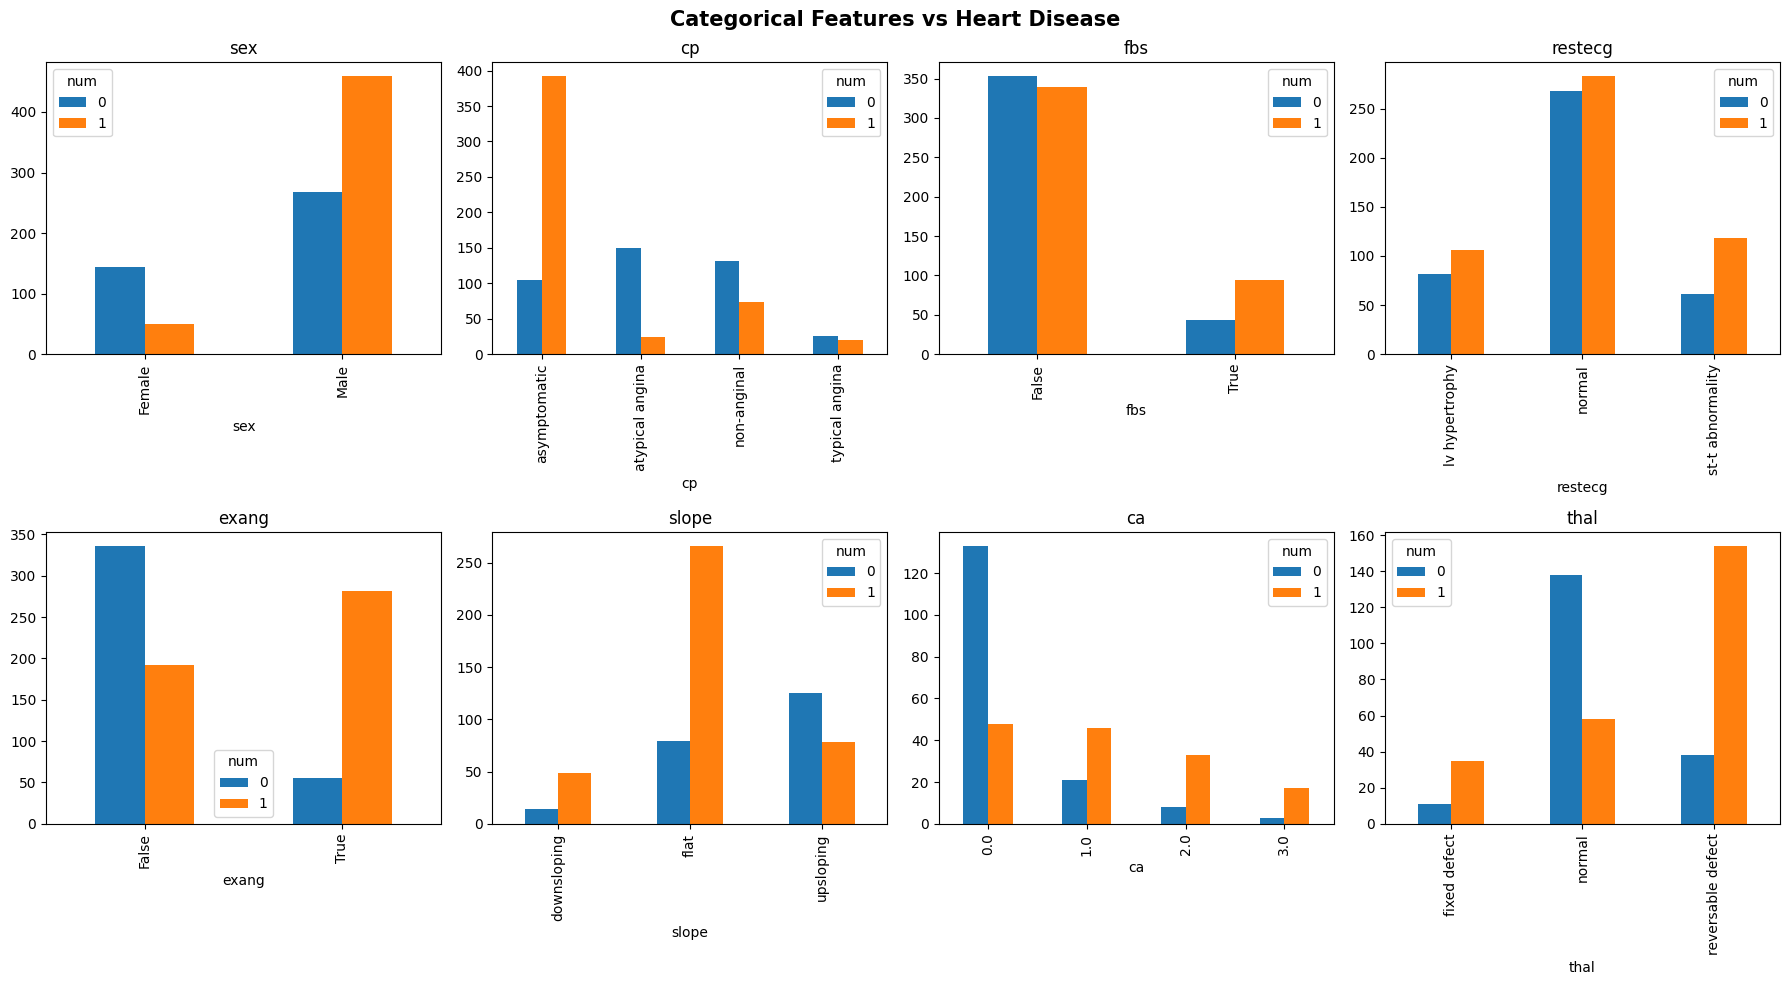

In [479]:
import matplotlib.pyplot as plt
import pandas as pd

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    pd.crosstab(df[col], df['num']).plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)

plt.suptitle('Categorical Features vs Heart Disease', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

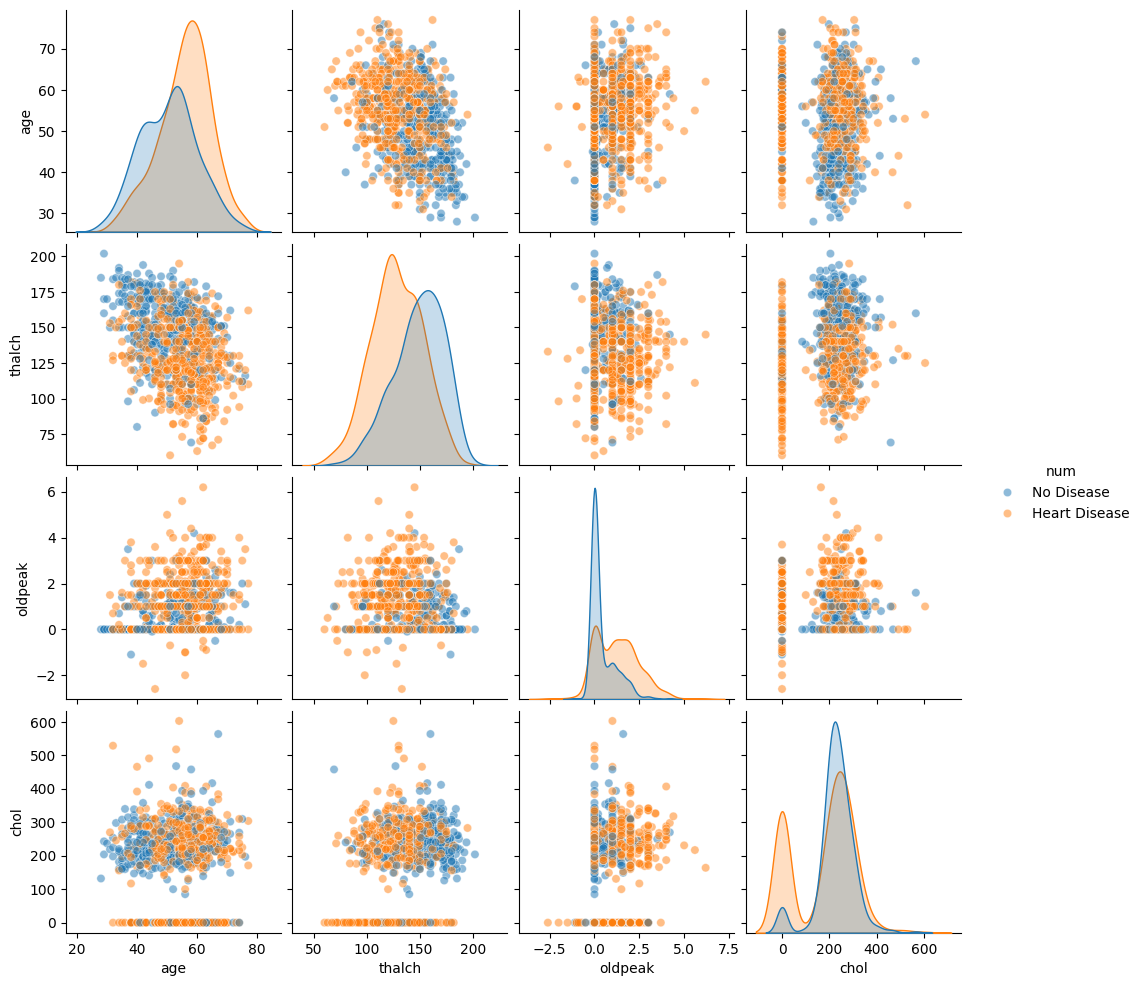

In [482]:
import seaborn as sns

key_features = ['age', 'thalch', 'oldpeak', 'chol', 'num']
pair_df = df[key_features].copy()
pair_df['num'] = pair_df['num'].map({0: 'No Disease', 1: 'Heart Disease'})
sns.pairplot(pair_df, hue='num', diag_kind='kde', plot_kws={'alpha':0.5})
plt.show()

In [434]:
# for col in df.columns:
#     df[col] = pd.to_numeric(df[col], errors='coerce')

In [435]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [436]:
df.dtypes

age         float64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

In [437]:
# Convert boolean-like columns to integers
for col in ['fbs', 'exang']:
    df[col] = df[col].astype(int)

In [438]:
df.drop(columns=['dataset'], inplace=True)

In [ ]:
cat_cols = ['sex', 'cp', 'restecg', 'slope','thal',]


In [440]:
# --- one hot encoding for categorical variables ---
from sklearn.preprocessing import OneHotEncoder
import pandas as pd


df = df.reset_index(drop=True)


encoder = OneHotEncoder(sparse_output=False)
encoder_arr = encoder.fit_transform(df[cat_cols])

encoded_cols = encoder.get_feature_names_out(cat_cols)
encoded_df = pd.DataFrame(encoder_arr, columns=encoded_cols)

encoded_df = encoded_df.reset_index(drop=True)



In [441]:
# Drop original categorical columns
df = df.drop(columns=cat_cols)

# Concatenate
df = pd.concat([df, encoded_df], axis=1)

df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,sex_Female,...,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_Unknown,thal_fixed defect,thal_normal,thal_reversable defect
0,1.007386,0.705176,0.303643,1,0.489727,0,1.368109,-0.361400,0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.432034,1.518569,0.789967,0,-1.181478,1,0.611589,4.411152,1,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.432034,-0.650479,0.266939,0,-0.345875,1,1.651804,2.820301,1,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-1.752828,-0.108217,0.459634,0,1.961979,0,2.502889,-0.361400,0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-1.328180,-0.108217,0.037541,0,1.365120,0,0.517024,-0.361400,0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [442]:
X = df.drop('num', axis=1)
y = df['num']



In [443]:
X.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,sex_Female,sex_Male,...,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_Unknown,thal_fixed defect,thal_normal,thal_reversable defect
0,1.007386,0.705176,0.303643,1,0.489727,0,1.368109,-0.361400,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.432034,1.518569,0.789967,0,-1.181478,1,0.611589,4.411152,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.432034,-0.650479,0.266939,0,-0.345875,1,1.651804,2.820301,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-1.752828,-0.108217,0.459634,0,1.961979,0,2.502889,-0.361400,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-1.328180,-0.108217,0.037541,0,1.365120,0,0.517024,-0.361400,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [444]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


print(f"Train size : {X_train.shape[0]}")
print(f"Test size  : {X_test.shape[0]}")

Train size : 736
Test size  : 184


In [445]:
# Define and train the model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [446]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Model trained.")
print(f"\nTraining Accuracy : {accuracy_score(y_train, model.predict(X_train)):.4f}")
print(f"Test Accuracy     : {accuracy_score(y_test, y_pred):.4f}")

Model trained.

Training Accuracy : 0.8288
Test Accuracy     : 0.8207


In [448]:
# --- 7.2 Classification Report ---
print('\nCLASSIFICATION REPORT:')
print('='*50)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))


CLASSIFICATION REPORT:
               precision    recall  f1-score   support

   No Disease       0.83      0.76      0.79        82
Heart Disease       0.82      0.87      0.84       102

     accuracy                           0.82       184
    macro avg       0.82      0.81      0.82       184
 weighted avg       0.82      0.82      0.82       184



In [449]:
cm= confusion_matrix(y_test, y_pred)
print('\nCONFUSION MATRIX:')
print('='*50)
print(cm)



CONFUSION MATRIX:
[[62 20]
 [13 89]]


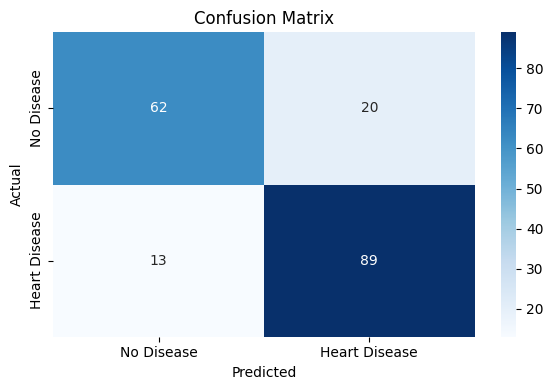

In [461]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'],
            )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


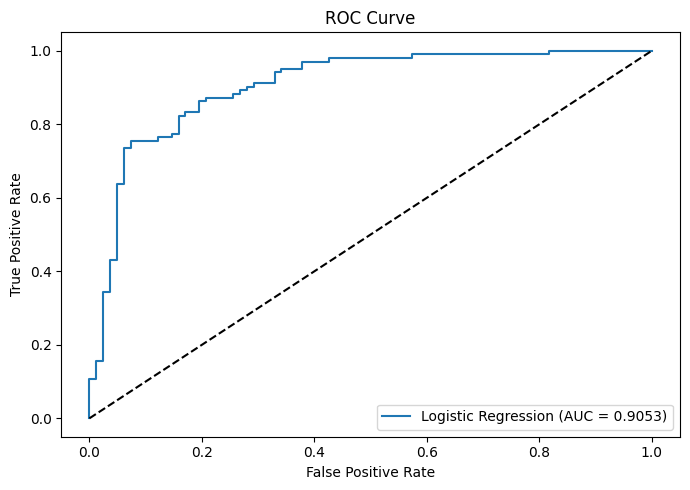

ROC-AUC Score: 0.9053


In [451]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr,
         label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

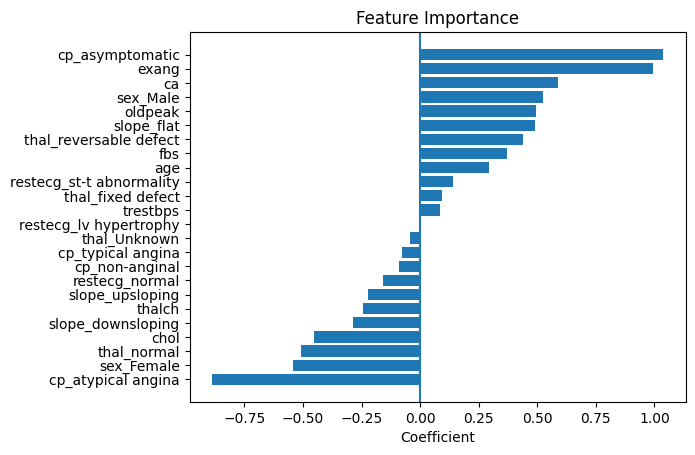

Top positive features:
            Feature  Coefficient
6           oldpeak     0.493835
9          sex_Male     0.523738
7                ca     0.589713
5             exang     0.992875
10  cp_asymptomatic     1.037199

Top negative features:
               Feature  Coefficient
11  cp_atypical angina    -0.887907
8           sex_Female    -0.541927
22         thal_normal    -0.506472
2                 chol    -0.454387
17   slope_downsloping    -0.288297


In [452]:
# Feature importance

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient")

# Plot
plt.barh(coeff_df["Feature"], coeff_df["Coefficient"])
plt.axvline(0)

plt.xlabel("Coefficient")
plt.title("Feature Importance")
plt.show()

# Top features
print("Top positive features:")
print(coeff_df.tail(5))

print("\nTop negative features:")
print(coeff_df.head(5))